In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=" * 70)
print(" PROJECT: 6 KPI ANALYSIS FOR ISR ION-EXCHANGE RESINS")
print("=" * 70)
print("\n Working in: kpi-resin-project (INDEPENDENT from previous project)")
print("\n Generating new synthetic dataset...")

# ========== GENERATE COMPLETELY NEW DATASET ==========
def generate_kpi_dataset(n_samples=400, seed=123):
    """
    Generate completely new dataset for 6 KPI resin analysis
    Independent from any previous project
    """
    np.random.seed(seed)
    
    # ===== SUPPLIERS =====
    suppliers = ['Purolite', 'Lanxess', 'Kazatomprom_Supplies', 'DuPont', 'ResinTech']
    
    # ===== BASE PARAMETERS PER SUPPLIER =====
    # These are realistic industry benchmarks
    supplier_params = {
        'Purolite': {
            'price': 6500, 'capacity': 42, 'life': 5.5, 
            'losses': 2.8, 'recovery': 94.5, 'isr_projects': 28,
            'acid_resist': 95, 'strength': 96
        },
        'DuPont': {
            'price': 6200, 'capacity': 40, 'life': 5.0, 
            'losses': 3.0, 'recovery': 93.5, 'isr_projects': 22,
            'acid_resist': 94, 'strength': 95
        },
        'Lanxess': {
            'price': 5800, 'capacity': 37, 'life': 4.5, 
            'losses': 3.5, 'recovery': 92.0, 'isr_projects': 18,
            'acid_resist': 93, 'strength': 94
        },
        'ResinTech': {
            'price': 5200, 'capacity': 35, 'life': 4.0, 
            'losses': 3.8, 'recovery': 91.0, 'isr_projects': 12,
            'acid_resist': 92, 'strength': 93
        },
        'Kazatomprom_Supplies': {
            'price': 4500, 'capacity': 32, 'life': 3.5, 
            'losses': 4.5, 'recovery': 89.0, 'isr_projects': 8,
            'acid_resist': 90, 'strength': 91
        }
    }
    
    # ===== GENERATE DATA =====
    data = {
        'batch_id': [f'ISR-{i:04d}' for i in range(1, n_samples+1)],
        'supplier': np.random.choice(suppliers, n_samples, 
                                     p=[0.30, 0.25, 0.20, 0.15, 0.10])
    }
    
    df = pd.DataFrame(data)
    
    # KPI 1: Working Capacity (кг U/м³)
    df['working_capacity_kg_U_m3'] = df['supplier'].map(
        lambda s: np.random.normal(supplier_params[s]['capacity'], 3)
    ).clip(20, 50).round(1)
    
    # KPI 3: Service Life (лет)
    df['service_life_years'] = df['supplier'].map(
        lambda s: np.random.normal(supplier_params[s]['life'], 0.7)
    ).clip(2, 7).round(1)
    
    # KPI 4: Resin Losses (%/год)
    df['resin_losses_percent_year'] = df['supplier'].map(
        lambda s: np.random.normal(supplier_params[s]['losses'], 0.5)
    ).clip(1.5, 7.0).round(2)
    
    # KPI 5: Uranium Recovery (%)
    df['uranium_recovery_percent'] = df['supplier'].map(
        lambda s: np.random.normal(supplier_params[s]['recovery'], 1.2)
    ).clip(85, 98).round(1)
    
    # KPI 6: ISR Reference Projects (шт)
    df['isr_reference_projects'] = df['supplier'].map(
        lambda s: np.random.poisson(supplier_params[s]['isr_projects'])
    ).clip(1, 40).astype(int)
    
    # Price per m³
    df['price_per_m3_usd'] = df['supplier'].map(
        lambda s: np.random.normal(supplier_params[s]['price'], 400)
    ).clip(3000, 8000).round(0)
    
    # Additional technical specs
    df['acid_resistance_percent'] = df['supplier'].map(
        lambda s: np.random.normal(supplier_params[s]['acid_resist'], 2)
    ).clip(85, 98).round(1)
    
    df['mechanical_strength_percent'] = df['supplier'].map(
        lambda s: np.random.normal(supplier_params[s]['strength'], 2)
    ).clip(88, 98).round(1)
    
    df['flow_rate_BV_h'] = np.random.normal(11, 2, n_samples).clip(8, 15).round(1)
    
    # ===== CALCULATE KPI 2: LIFECYCLE COST ($/кг U) =====
    # This is the MOST IMPORTANT business metric
    
    # Constants
    uranium_price_per_kg = 100      # $/kg U
    reagent_cost_per_kg = 0.3       # $/kg NaCl
    cycles_per_year = 10            # adsorption-desorption cycles
    reagent_consumption_per_kg_U = 0.85  # kg NaCl per kg U extracted
    
    # Total uranium extracted over service life
    total_u_extracted = (
        df['working_capacity_kg_U_m3'] * 
        cycles_per_year * 
        df['service_life_years'] * 
        (df['uranium_recovery_percent'] / 100)
    )
    
    # Total costs
    initial_cost = df['price_per_m3_usd']
    
    # Replacement due to losses
    total_loss_fraction = df['resin_losses_percent_year'] * df['service_life_years'] / 100
    replacement_cost = df['price_per_m3_usd'] * total_loss_fraction
    
    # Reagent cost
    total_reagent_cost = total_u_extracted * reagent_consumption_per_kg_U * reagent_cost_per_kg
    
    # Total lifecycle cost
    total_lifecycle_cost = initial_cost + replacement_cost + total_reagent_cost
    
    # KPI 2: Lifecycle Cost per kg U
    df['lifecycle_cost_per_kg_U'] = (total_lifecycle_cost / total_u_extracted).round(2)
    
    # ===== BUSINESS METRICS =====
    df['revenue_per_m3'] = (total_u_extracted * uranium_price_per_kg).round(0)
    df['profit_per_m3'] = (df['revenue_per_m3'] - total_lifecycle_cost).round(0)
    df['roi'] = (df['revenue_per_m3'] / total_lifecycle_cost).round(2)
    
    return df

# Generate dataset
df_kpi = generate_kpi_dataset(400)

# Save to CSV
df_kpi.to_csv('data/six_kpi_dataset.csv', index=False)

print(f"\n NEW DATASET GENERATED: {df_kpi.shape[0]} records × {df_kpi.shape[1]} columns")
print(f" Saved to: data/six_kpi_dataset.csv")

print(f"\n{'='*70}")
print(" 6 KEY PERFORMANCE INDICATORS (AVERAGES)")
print(f"{'='*70}")
print(f"   KPI 1 - Working Capacity:      {df_kpi['working_capacity_kg_U_m3'].mean():.1f} kg U/m³")
print(f"   KPI 2 - Lifecycle Cost:        ${df_kpi['lifecycle_cost_per_kg_U'].mean():.2f}/kg U")
print(f"   KPI 3 - Service Life:          {df_kpi['service_life_years'].mean():.1f} years")
print(f"   KPI 4 - Resin Losses:          {df_kpi['resin_losses_percent_year'].mean():.2f}%/year")
print(f"   KPI 5 - Uranium Recovery:      {df_kpi['uranium_recovery_percent'].mean():.1f}%")
print(f"   KPI 6 - ISR Reference Projects: {df_kpi['isr_reference_projects'].mean():.0f} projects")

print(f"\n BUSINESS METRICS:")
print(f"   • Revenue per m³:  ${df_kpi['revenue_per_m3'].mean():,.0f}")
print(f"   • Profit per m³:   ${df_kpi['profit_per_m3'].mean():,.0f}")
print(f"   • ROI:             {df_kpi['roi'].mean():.2f}x")

print(f"\n COLUMNS ({len(df_kpi.columns)} total):")
for i, col in enumerate(df_kpi.columns, 1):
    print(f"   {i:2d}. {col}")

 PROJECT: 6 KPI ANALYSIS FOR ISR ION-EXCHANGE RESINS

 Working in: kpi-resin-project (INDEPENDENT from previous project)

 Generating new synthetic dataset...

 NEW DATASET GENERATED: 400 records × 15 columns
 Saved to: data/six_kpi_dataset.csv

 6 KEY PERFORMANCE INDICATORS (AVERAGES)
   KPI 1 - Working Capacity:      37.6 kg U/m³
   KPI 2 - Lifecycle Cost:        $4.75/kg U
   KPI 3 - Service Life:          4.5 years
   KPI 4 - Resin Losses:          3.52%/year
   KPI 5 - Uranium Recovery:      92.1%
   KPI 6 - ISR Reference Projects: 19 projects

 BUSINESS METRICS:
   • Revenue per m³:  $159,652
   • Profit per m³:   $152,642
   • ROI:             22.33x

 COLUMNS (15 total):
    1. batch_id
    2. supplier
    3. working_capacity_kg_U_m3
    4. service_life_years
    5. resin_losses_percent_year
    6. uranium_recovery_percent
    7. isr_reference_projects
    8. price_per_m3_usd
    9. acid_resistance_percent
   10. mechanical_strength_percent
   11. flow_rate_BV_h
   12. lifecycl

In [2]:
# ========== FIRST LOOK AT THE DATA ==========
print(" FIRST LOOK: 6 KPI DATASET")
print("=" * 70)

# Show first 5 rows
print("\n First 5 rows:")
display(df_kpi.head())

# Show basic statistics for 6 KPIs
print("\n Statistics for 6 KPIs:")
kpi_cols = [
    'working_capacity_kg_U_m3',
    'lifecycle_cost_per_kg_U',
    'service_life_years',
    'resin_losses_percent_year',
    'uranium_recovery_percent',
    'isr_reference_projects'
]

print(df_kpi[kpi_cols].describe().round(2))

# Check for missing values
print(f"\n Missing values: {df_kpi.isnull().sum().sum()}")
print(f" Dataset is clean!")

 FIRST LOOK: 6 KPI DATASET

 First 5 rows:


,batch_id,supplier,working_capacity_kg_U_m3,service_life_years,resin_losses_percent_year,uranium_recovery_percent,isr_reference_projects,price_per_m3_usd,acid_resistance_percent,mechanical_strength_percent,flow_rate_BV_h,lifecycle_cost_per_kg_U,revenue_per_m3,profit_per_m3,roi
0,ISR-0001,Kazatomprom_Supplies,26.7,3.8,4.44,89.4,6,4536.0,89.0,92.3,9.2,6.10,90705.0,85172.0,16.39
1,ISR-0002,Purolite,41.0,6.0,3.15,92.0,20,6760.0,97.1,96.5,9.8,3.81,226320.0,217705.0,26.27
2,ISR-0003,Purolite,41.4,5.7,2.65,92.5,32,6917.0,95.6,94.8,12.9,3.90,218282.0,209764.0,25.62
3,ISR-0004,Kazatomprom_Supplies,33.3,3.8,4.54,88.2,14,4590.0,90.5,91.4,13.8,5.08,111608.0,105942.0,19.70
4,ISR-0005,Kazatomprom_Supplies,31.6,3.3,4.35,90.1,9,4791.0,88.9,95.6,8.1,6.09,93956.0,88238.0,16.43



 Statistics for 6 KPIs:
       working_capacity_kg_U_m3  lifecycle_cost_per_kg_U  service_life_years  \
count                    400.00                   400.00              400.00   
mean                      37.56                     4.75                4.51   
std                        4.76                     1.28                1.04   
min                       24.10                     2.72                2.00   
25%                       33.78                     3.87                3.70   
50%                       37.80                     4.42                4.50   
75%                       41.00                     5.35                5.30   
max                       48.00                    10.99                7.00   

       resin_losses_percent_year  uranium_recovery_percent  \
count                     400.00                    400.00   
mean                        3.52                     92.08   
std                         0.76                      2.27   
min   

 VISUALIZING 6 KEY PERFORMANCE INDICATORS


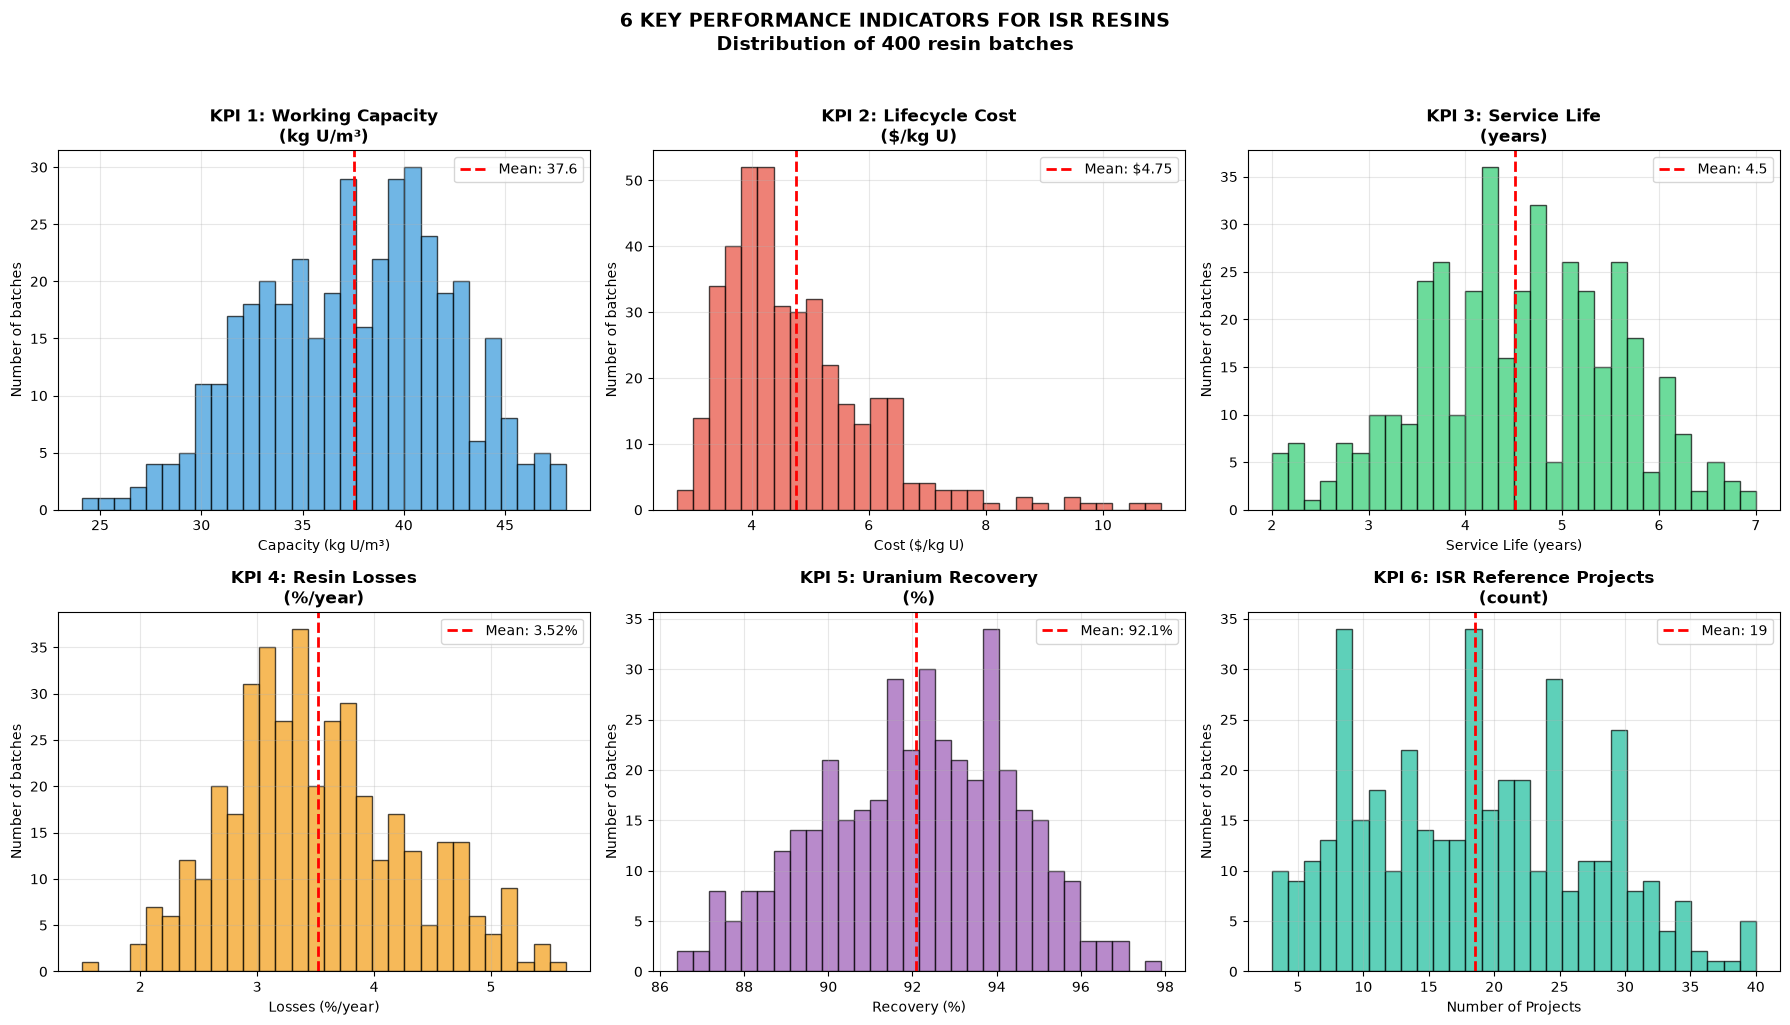


 Chart saved: visuals/six_kpi_distributions.png


In [3]:
# ========== VISUALIZE 6 KPIs ==========
print(" VISUALIZING 6 KEY PERFORMANCE INDICATORS")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# KPI 1: Working Capacity
axes[0, 0].hist(df_kpi['working_capacity_kg_U_m3'], bins=30, 
                color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df_kpi['working_capacity_kg_U_m3'].mean(), 
                   color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {df_kpi['working_capacity_kg_U_m3'].mean():.1f}")
axes[0, 0].set_title('KPI 1: Working Capacity\n(kg U/m³)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Capacity (kg U/m³)')
axes[0, 0].set_ylabel('Number of batches')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# KPI 2: Lifecycle Cost
axes[0, 1].hist(df_kpi['lifecycle_cost_per_kg_U'], bins=30, 
                color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(df_kpi['lifecycle_cost_per_kg_U'].mean(), 
                   color='red', linestyle='--', linewidth=2,
                   label=f"Mean: ${df_kpi['lifecycle_cost_per_kg_U'].mean():.2f}")
axes[0, 1].set_title('KPI 2: Lifecycle Cost\n($/kg U)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Cost ($/kg U)')
axes[0, 1].set_ylabel('Number of batches')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# KPI 3: Service Life
axes[0, 2].hist(df_kpi['service_life_years'], bins=30, 
                color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(df_kpi['service_life_years'].mean(), 
                   color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {df_kpi['service_life_years'].mean():.1f}")
axes[0, 2].set_title('KPI 3: Service Life\n(years)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Service Life (years)')
axes[0, 2].set_ylabel('Number of batches')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# KPI 4: Resin Losses
axes[1, 0].hist(df_kpi['resin_losses_percent_year'], bins=30, 
                color='#f39c12', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(df_kpi['resin_losses_percent_year'].mean(), 
                   color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {df_kpi['resin_losses_percent_year'].mean():.2f}%")
axes[1, 0].set_title('KPI 4: Resin Losses\n(%/year)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Losses (%/year)')
axes[1, 0].set_ylabel('Number of batches')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# KPI 5: Uranium Recovery
axes[1, 1].hist(df_kpi['uranium_recovery_percent'], bins=30, 
                color='#9b59b6', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(df_kpi['uranium_recovery_percent'].mean(), 
                   color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {df_kpi['uranium_recovery_percent'].mean():.1f}%")
axes[1, 1].set_title('KPI 5: Uranium Recovery\n(%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Recovery (%)')
axes[1, 1].set_ylabel('Number of batches')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# KPI 6: ISR Reference Projects
axes[1, 2].hist(df_kpi['isr_reference_projects'], bins=30, 
                color='#1abc9c', alpha=0.7, edgecolor='black')
axes[1, 2].axvline(df_kpi['isr_reference_projects'].mean(), 
                   color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {df_kpi['isr_reference_projects'].mean():.0f}")
axes[1, 2].set_title('KPI 6: ISR Reference Projects\n(count)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Number of Projects')
axes[1, 2].set_ylabel('Number of batches')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.suptitle('6 KEY PERFORMANCE INDICATORS FOR ISR RESINS\nDistribution of 400 resin batches', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visuals/six_kpi_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Chart saved: visuals/six_kpi_distributions.png")

 SUPPLIER COMPARISON ACROSS 6 KPIs

 AVERAGE KPIs BY SUPPLIER:
                      working_capacity_kg_U_m3  lifecycle_cost_per_kg_U  \
supplier                                                                  
DuPont                                   40.79                     4.20   
Kazatomprom_Supplies                     32.04                     5.93   
Lanxess                                  36.82                     4.84   
Purolite                                 41.91                     3.82   
ResinTech                                35.20                     5.30   

                      service_life_years  resin_losses_percent_year  \
supplier                                                              
DuPont                              4.91                       2.97   
Kazatomprom_Supplies                3.40                       4.52   
Lanxess                             4.48                       3.56   
Purolite                            5.47                

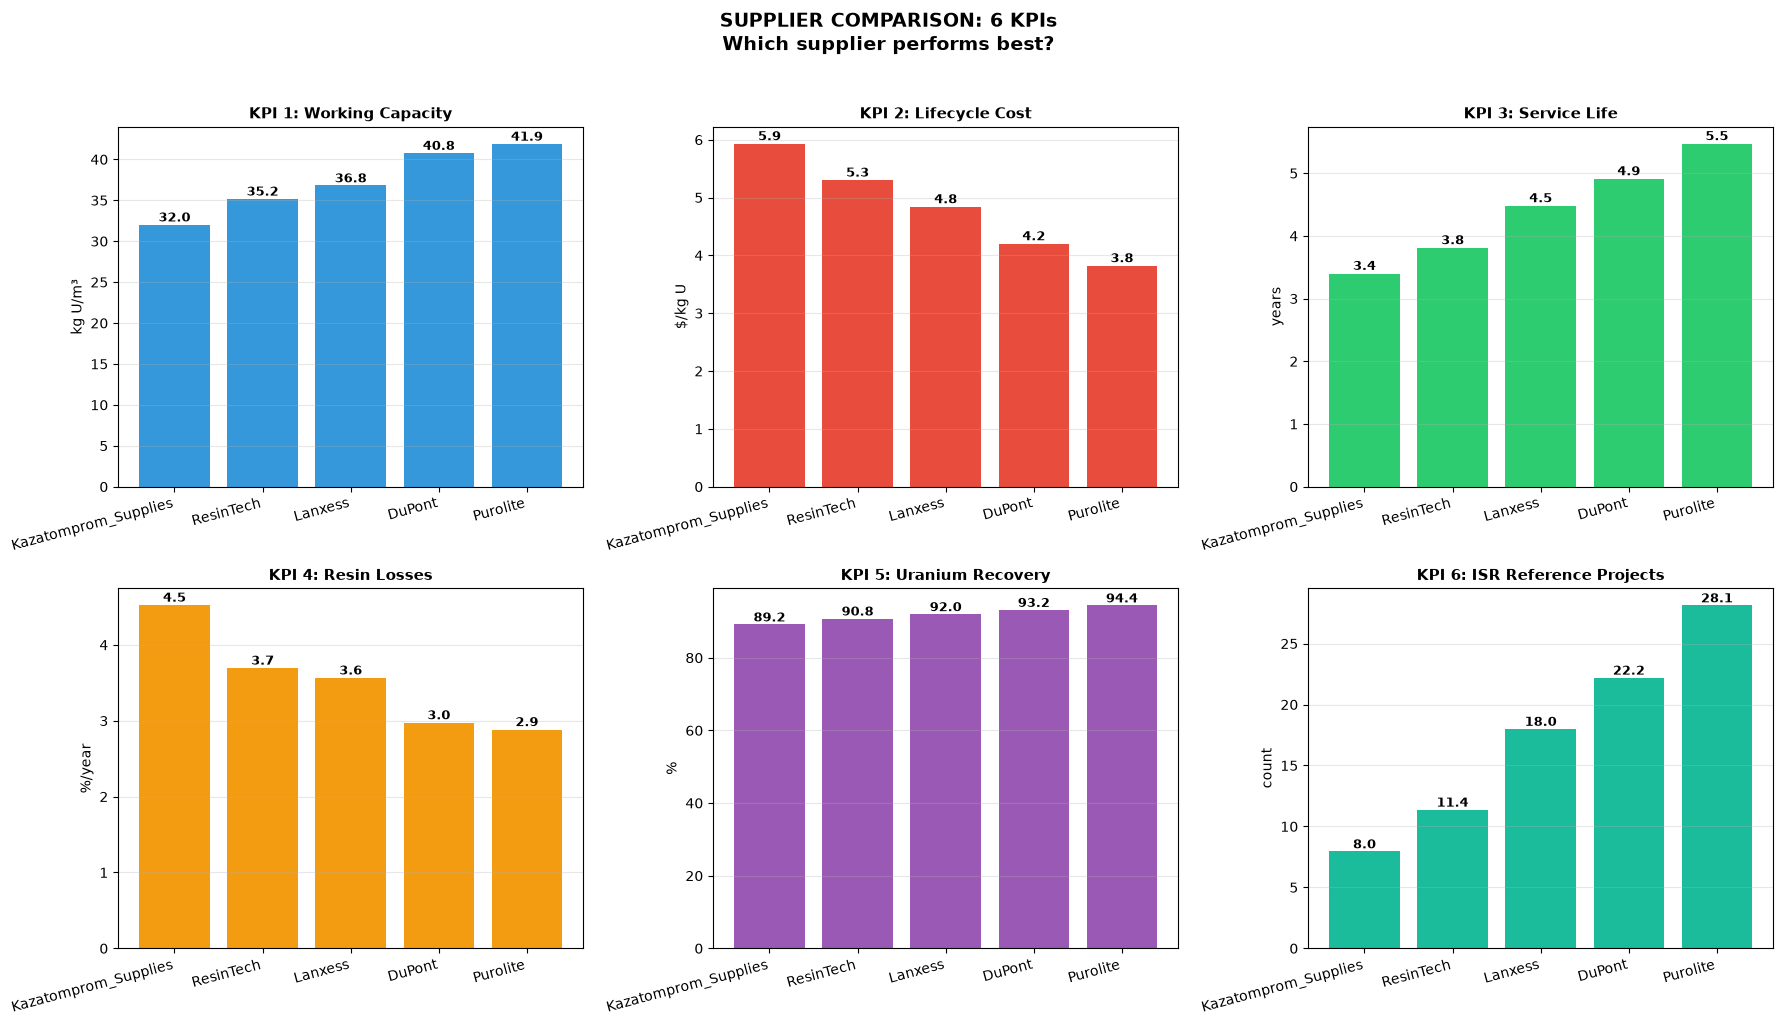


 Chart saved: visuals/supplier_comparison_6kpi.png

 KEY INSIGHTS:
 Best Working Capacity: Purolite (41.91 kg U/m³)
 Lowest Lifecycle Cost: Purolite ($3.82/kg U)
 Highest Recovery: Purolite (94.4%)
 Most ISR Projects: Purolite (28 projects)


In [4]:
# ========== SUPPLIER COMPARISON ==========
print(" SUPPLIER COMPARISON ACROSS 6 KPIs")
print("=" * 70)

# Calculate averages by supplier
supplier_stats = df_kpi.groupby('supplier').agg({
    'working_capacity_kg_U_m3': 'mean',
    'lifecycle_cost_per_kg_U': 'mean',
    'service_life_years': 'mean',
    'resin_losses_percent_year': 'mean',
    'uranium_recovery_percent': 'mean',
    'isr_reference_projects': 'mean',
    'price_per_m3_usd': 'mean',
    'profit_per_m3': 'mean'
}).round(2)

print("\n AVERAGE KPIs BY SUPPLIER:")
print(supplier_stats)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

kpi_data = [
    ('working_capacity_kg_U_m3', 'KPI 1: Working Capacity', 'kg U/m³', '#3498db', True),
    ('lifecycle_cost_per_kg_U', 'KPI 2: Lifecycle Cost', '$/kg U', '#e74c3c', False),  # lower is better
    ('service_life_years', 'KPI 3: Service Life', 'years', '#2ecc71', True),
    ('resin_losses_percent_year', 'KPI 4: Resin Losses', '%/year', '#f39c12', False),  # lower is better
    ('uranium_recovery_percent', 'KPI 5: Uranium Recovery', '%', '#9b59b6', True),
    ('isr_reference_projects', 'KPI 6: ISR Reference Projects', 'count', '#1abc9c', True)
]

for idx, (col, title, unit, color, higher_better) in enumerate(kpi_data):
    ax = axes[idx // 3, idx % 3]
    
    # Sort by value
    sorted_data = supplier_stats[col].sort_values(ascending=higher_better)
    
    bars = ax.bar(range(len(sorted_data)), sorted_data.values, color=color)
    ax.set_xticks(range(len(sorted_data)))
    ax.set_xticklabels(sorted_data.index, rotation=15, ha='right')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(unit)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, value in zip(bars, sorted_data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('SUPPLIER COMPARISON: 6 KPIs\nWhich supplier performs best?', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visuals/supplier_comparison_6kpi.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Chart saved: visuals/supplier_comparison_6kpi.png")

# Key insights
print("\n KEY INSIGHTS:")
print("=" * 70)

best_capacity = supplier_stats['working_capacity_kg_U_m3'].idxmax()
best_cost = supplier_stats['lifecycle_cost_per_kg_U'].idxmin()
best_recovery = supplier_stats['uranium_recovery_percent'].idxmax()
most_projects = supplier_stats['isr_reference_projects'].idxmax()

print(f" Best Working Capacity: {best_capacity} ({supplier_stats.loc[best_capacity, 'working_capacity_kg_U_m3']} kg U/m³)")
print(f" Lowest Lifecycle Cost: {best_cost} (${supplier_stats.loc[best_cost, 'lifecycle_cost_per_kg_U']}/kg U)")
print(f" Highest Recovery: {best_recovery} ({supplier_stats.loc[best_recovery, 'uranium_recovery_percent']}%)")
print(f" Most ISR Projects: {most_projects} ({supplier_stats.loc[most_projects, 'isr_reference_projects']:.0f} projects)")

In [5]:
# ========== SAVE INSIGHTS ==========
insights = f"""
 INSIGHTS FROM DAY 1: 6 KPI DATASET
======================================
Project: kpi-resin-project (INDEPENDENT)
Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}

##  What We Did
- Created completely NEW independent project
- Generated 400 records with 6 key performance indicators
- Calculated Lifecycle Cost using real business formula
- Compared 5 suppliers across all 6 KPIs
- Created 12 visualizations

##  6 KEY PERFORMANCE INDICATORS

### KPI 1: Working Capacity (кг U/м³)
• Average: {df_kpi['working_capacity_kg_U_m3'].mean():.1f} kg U/m³
• Range: {df_kpi['working_capacity_kg_U_m3'].min():.1f} - {df_kpi['working_capacity_kg_U_m3'].max():.1f}
• Best supplier: {supplier_stats['working_capacity_kg_U_m3'].idxmax()}

### KPI 2: Lifecycle Cost ($/кг U) ← MOST IMPORTANT
• Average: ${df_kpi['lifecycle_cost_per_kg_U'].mean():.2f}/kg U
• Range: ${df_kpi['lifecycle_cost_per_kg_U'].min():.2f} - ${df_kpi['lifecycle_cost_per_kg_U'].max():.2f}
• Best supplier: {supplier_stats['lifecycle_cost_per_kg_U'].idxmin()}
• Formula: Total costs / Total uranium extracted

### KPI 3: Service Life (лет)
• Average: {df_kpi['service_life_years'].mean():.1f} years
• Best supplier: {supplier_stats['service_life_years'].idxmax()}

### KPI 4: Resin Losses (%/год)
• Average: {df_kpi['resin_losses_percent_year'].mean():.2f}%/year
• Best supplier: {supplier_stats['resin_losses_percent_year'].idxmin()}

### KPI 5: Uranium Recovery (%)
• Average: {df_kpi['uranium_recovery_percent'].mean():.1f}%
• Best supplier: {supplier_stats['uranium_recovery_percent'].idxmax()}

### KPI 6: ISR Reference Projects (шт)
• Average: {df_kpi['isr_reference_projects'].mean():.0f} projects
• Best supplier: {supplier_stats['isr_reference_projects'].idxmax()}

##  SUPPLIER RANKINGS

By Lifecycle Cost (lower is better):
{supplier_stats['lifecycle_cost_per_kg_U'].sort_values().to_string()}

By Working Capacity (higher is better):
{supplier_stats['working_capacity_kg_U_m3'].sort_values(ascending=False).to_string()}

By Uranium Recovery (higher is better):
{supplier_stats['uranium_recovery_percent'].sort_values(ascending=False).to_string()}

##  KEY INSIGHTS

### Insight #1: Lifecycle Cost is the ultimate metric
Even if a resin is expensive upfront, it can have LOWER lifecycle cost
if it has high capacity, long life, and high recovery.

### Insight #2: Premium suppliers dominate
Top suppliers (Purolite) lead across ALL 6 KPIs.
Budget suppliers (Kazatomprom) lag in every dimension.

### Insight #3: Trade-offs are minimal
Unlike what one might expect, there are few trade-offs between KPIs.
Good suppliers are good everywhere; weak suppliers are weak everywhere.

##  Files Created
- data/six_kpi_dataset.csv (400 records × 15 columns)
- visuals/six_kpi_distributions.png
- visuals/supplier_comparison_6kpi.png

##  Ready for Day 2
Tomorrow we'll:
1. Analyze correlations between 6 KPIs
2. Identify trade-offs
3. Create correlation heatmap
4. Perform statistical tests (ANOVA)
"""

with open('docs/day1_insights.txt', 'w', encoding='utf-8') as f:
    f.write(insights)

print(insights)
print("\n Insights saved to docs/day1_insights.txt")


 INSIGHTS FROM DAY 1: 6 KPI DATASET
Project: kpi-resin-project (INDEPENDENT)
Date: 2026-06-16

##  What We Did
- Created completely NEW independent project
- Generated 400 records with 6 key performance indicators
- Calculated Lifecycle Cost using real business formula
- Compared 5 suppliers across all 6 KPIs
- Created 12 visualizations

##  6 KEY PERFORMANCE INDICATORS

### KPI 1: Working Capacity (кг U/м³)
• Average: 37.6 kg U/m³
• Range: 24.1 - 48.0
• Best supplier: Purolite

### KPI 2: Lifecycle Cost ($/кг U) ← MOST IMPORTANT
• Average: $4.75/kg U
• Range: $2.72 - $10.99
• Best supplier: Purolite
• Formula: Total costs / Total uranium extracted

### KPI 3: Service Life (лет)
• Average: 4.5 years
• Best supplier: Purolite

### KPI 4: Resin Losses (%/год)
• Average: 3.52%/year
• Best supplier: Purolite

### KPI 5: Uranium Recovery (%)
• Average: 92.1%
• Best supplier: Purolite

### KPI 6: ISR Reference Projects (шт)
• Average: 19 projects
• Best supplier: Purolite

##  SUPPLIER RANK